# Cross-layer EDA 03: RNA Cross-Source Concordance

## 1. The biological question

Three independent groups measured RNA expression for (overlapping) sets of the same cell lines:
DepMap (RNA-seq, one lab, one pipeline -- the primary expression source), the Human Protein Atlas
(HPA, RNA-seq, a different lab and normalisation pipeline), and public GEO submissions (mostly
older microarray-era technology, pooled across many independent studies). If a gene's expression
level agrees across two or three of these **independent measurement platforms** for the same cell
line, that agreement is evidence the underlying biological signal is real -- not an artefact of one
lab's pipeline, one normalisation choice, or one batch. If the platforms disagree, that is a
limitation to surface to the user, not a discrepancy to quietly average away.

This is precisely the second half of `docs/PROJECT_ARCHITECTURE.md` \u00a78's confidence design:

> **Consistency** -- whether independent sources agree where both exist. Cross-source RNA agreement
> (DepMap versus HPA) is the natural instance: two labs, two platforms, one quantity.

and it is why \u00a74 states plainly: *"HPA and DepMap RNA are independent measurements of the same
quantity. Their agreement is a confidence signal, not redundancy to deduplicate away."* The same
document's missing-evidence rule (\u00a77) forbids silently blending two sources into one number --
consistency has to be measured and reported, never folded into a single averaged value. This
notebook measures it, and its numbers feed `docs/PROJECT_ARCHITECTURE.md` \u00a76's per-layer
admission gate (specifically GEO RNA's open **A3, calibratable** question) and \u00a78's confidence
design directly.

**Never claim causation from correlation.** A high per-model correlation between two RNA platforms
says the two measurements move together for that cell line's transcriptome -- it says nothing about
*why*, and a low correlation could reflect real biology (a genuinely unusual sample), a batch
artefact, or an identity-resolution error upstream. Distinguishing those is exactly what \u00a79's
biological-example spot-checks are for, not something a single correlation number can resolve on
its own.

## 2. Source, release, and table grain

Three RNA layers, all `data/raw/gene_expression/`, plus the identity/bridge tables already
established in cross-layer notebook 01 (spine) and notebook 02 (lineage strata):

| # | File | Grain | Scale |
|---|---|---|---|
| 1 | `1_4_hpa_rna_celline.tsv` | long: (`Gene` \u00d7 `Cell line`), ~24.3M rows | `nTPM`, raw |
| 2 | `2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv` | wide: row = `ProfileID` | `log2(TPM+1)`, already log-scaled -- **primary** |
| 3 | `3_GEOexpression.txt` | wide: rows = `ENSG` gene, cols = `GSM` sample | raw, **not** log-scaled |

Release dates for files 1-3 are recorded as "TBD" in `docs/reference/DATA_SOURCES.md` -- AZ's
delivery does not carry a release date for these three files, so none is invented here.

This notebook reuses, rather than re-derives, three pieces of prior work, per the house convention
that an earlier notebook explains the "why" once and later notebooks reuse it tersely:

- **The gated identity spine and `lineage_canonical`** (cross-layer notebook 01 \u00a73-\u00a75) --
  rebuilt inline in \u00a73 below, with the same hard `assert`s notebook 02 used, checked against
  01/02's cited values before anything new is computed.
- **The `n>=30` minimum-group-size floor and the lineage-coverage strata** (cross-layer notebook 02
  \u00a76, adopted from `docs/plan/CONSTRAINTS.md` \u00a73) -- reused for \u00a77's lineage
  stratification, not re-derived; notebook 02 also named GEO RNA as its most lineage-concentrated
  layer (top-3-lineage ratio x1.27, over Lung/Lymphoid/Breast), which \u00a78 below tests directly.
- **The exact join logic for each RNA source** -- HPA's 3-hop bridge (single-layer notebook 01
  \u00a76), DepMap's `ProfileID` \u2192 `ModelID` bridge via file 8 filtered to `Datatype=='rna'`
  (single-layer notebook 02 \u00a76), and GEO's 3-hop bridge with its explicit `log1p` decision and
  its open batch-effect question (single-layer notebook 03 \u00a75 and its "Decisions carried
  forward", quoted in full in \u00a78 below).

## Column dictionary

| Column | Meaning | Source |
|---|---|---|
| `model_id` | union identifier (`DepMap_ID` / `ModelID` share one `ACH-xxxxxx` space) | notebook 01 \u00a73 |
| `lineage_canonical` | modern `OncotreeLineage` first, legacy `lineage` fallback | notebook 01 \u00a75 |
| `ENSG...` (DepMap table columns) | Ensembl gene ID, extracted from the packed `SYMBOL (ENSG...)` header | file 2 |
| `Gene` (HPA, GEO) | Ensembl gene ID -- **the only safe join key**, per `data/raw/_.md`'s 10-symbol-collision warning | files 1, 3 |
| per-model Spearman `rho` | rank correlation of one cell line's expression profile between two platforms, computed across the shared gene set | this notebook \u00a76 |

## 3. Rebuild the identity spine and `lineage_canonical` (as established in notebook 01 §3-§5)

Reused verbatim from notebooks 01/02: union `DepMap_ID` (file 9) with `ModelID` (file 17), gate to
`Species of origin` containing `Homo sapiens` and `Category == 'Cancer cell line'` in Cellosaurus
(file 7) via the RRID bridge, then build `lineage_canonical` (modern `OncotreeLineage` first,
legacy `lineage` fallback). A reproduction, not a new derivation -- the assertions right after are
the point of doing it again here.

In [1]:
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    # Walks up from the notebook's working directory until data/raw/gene_expression is found -- the same anchor notebooks 01/02 use.
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
NOMENCLATURE = RAW / 'nomenclature'
AUGMENTED = ROOT / 'data' / 'augmented'
print(f"Project root: {ROOT}")

Project root: D:\uob\final\az-team25


In [2]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
df17 = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')

legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df17['ModelID'].dropna())
spine_ids = sorted(legacy_ids | modern_ids)

spine = pd.DataFrame({'model_id': spine_ids})
spine = spine.merge(
    df9[['DepMap_ID', 'RRID', 'lineage', 'primary_disease', 'CCLE_Name']],
    left_on='model_id', right_on='DepMap_ID', how='left',
).drop(columns=['DepMap_ID']).rename(
    columns={'RRID': 'RRID_legacy', 'lineage': 'lineage_legacy', 'primary_disease': 'disease_legacy'}
)
spine = spine.merge(
    df17[['ModelID', 'RRID', 'OncotreeLineage', 'OncotreePrimaryDisease', 'CCLEName']],
    left_on='model_id', right_on='ModelID', how='left',
).drop(columns=['ModelID']).rename(
    columns={'RRID': 'RRID_modern', 'OncotreeLineage': 'lineage_modern', 'OncotreePrimaryDisease': 'disease_modern'}
)
spine['in_legacy'] = spine['model_id'].isin(legacy_ids)
spine['in_modern'] = spine['model_id'].isin(modern_ids)
assert spine['model_id'].is_unique, "model_id must be a clean primary key for the spine"

df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df7[
    df7['Species of origin'].str.contains('Homo sapiens', na=False)
    & (df7['Category'] == 'Cancer cell line')
]
human_cancer_accessions = set(human_cancer['Accession (CVCL_xxxx)'].dropna())

spine['RRID'] = spine['RRID_legacy'].combine_first(spine['RRID_modern'])
spine['passes_species_cancer_gate'] = spine['RRID'].isin(human_cancer_accessions)
gated_spine = spine[spine['passes_species_cancer_gate']].copy().reset_index(drop=True)
N = len(gated_spine)

gated_spine['lineage_canonical'] = gated_spine['lineage_modern'].combine_first(gated_spine['lineage_legacy'])
gated_spine['display_name'] = gated_spine['CCLEName'].combine_first(gated_spine['CCLE_Name'])

print(f"Rebuilt gated spine size: N = {N}")
print(f"Rebuilt lineage_canonical categories: {gated_spine['lineage_canonical'].nunique()}")
print(f"Rebuilt lineage_canonical missing: {gated_spine['lineage_canonical'].isna().sum()}")

# Sanity check against notebooks 01/02's cited numbers -- stop here if this does not match, per the
# house rule that a downstream notebook never silently diverges from an upstream one.
assert N == 1874, f"Spine size {N} does not match notebooks 01/02's cited N=1874"
assert gated_spine['lineage_canonical'].nunique() == 38, "lineage_canonical category count does not match notebooks 01/02"
assert gated_spine['lineage_canonical'].isna().sum() == 0, "lineage_canonical should have 0 missing"
print("\nMatches notebooks 01/02's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED")

Rebuilt gated spine size: N = 1874
Rebuilt lineage_canonical categories: 38
Rebuilt lineage_canonical missing: 0

Matches notebooks 01/02's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED


### Why this EDA check matters

If this rebuild had drifted from notebooks 01/02's numbers, every model-overlap and lineage figure
below would be measured against a different, silently-changed population -- exactly the failure
mode `eda/_.md` warns against. The assertions above are a hard stop, not a comment: they confirm the
same 1,874-line, 38-category spine underlies every count in this notebook.

## 4. Rebuild the three RNA-layer coverage flags (notebook 01 §6a-c) and the n>=30 floor (notebook 02 §6)

Reused verbatim from notebooks 01/02 -- the same files, the same 3-hop bridges for HPA and GEO
(`bridge_via_rrid`, allowing one Cellosaurus accession to legitimately reach two `model_id`s), the
same `Datatype=='rna'` filter for DepMap via file 8. Coverage is checked against 01/02's cited
56.6% / 73.8% / 31.6% before anything new is built. The n>=30 lineage floor (notebook 02 §6,
from `docs/plan/CONSTRAINTS.md` §3) is reused as-is, not re-derived, for §7's stratification
below.

In [3]:
rrid_to_models = gated_spine.dropna(subset=['RRID']).groupby('RRID')['model_id'].apply(set).to_dict()


def bridge_via_rrid(rrid_series: pd.Series) -> set:
    # Resolves a Series of Cellosaurus accessions to the set of gated-spine model_ids they touch --
    # one accession can legitimately reach two model_ids (notebook 01 found 6 such cases, 12 rows).
    out = set()
    for rrid in rrid_series.dropna():
        out |= rrid_to_models.get(rrid, set())
    return out


hpa_names = pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t', usecols=['Cell line'])['Cell line'].unique()
df11 = pd.read_csv(NOMENCLATURE / '11_hpa_rna_celline_description.tsv', sep='\t', usecols=['Cell line', 'Cellosaurus ID'])
name_to_cvcl = df11.dropna(subset=['Cell line']).drop_duplicates('Cell line').set_index('Cell line')['Cellosaurus ID']
hpa_models = bridge_via_rrid(pd.Series(hpa_names).map(name_to_cvcl).dropna())

rna_profile_ids = set(pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=[0]).iloc[:, 0])
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df8_rna = df8[df8['Datatype'] == 'rna']
depmap_models = set(df8_rna.loc[df8_rna['ProfileID'].isin(rna_profile_ids), 'ModelID'].dropna()) & set(gated_spine['model_id'])

geo_header = pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t', nrows=0).columns
gsm_cols = [c for c in geo_header if c.startswith('GSM')]
df10 = pd.read_csv(NOMENCLATURE / '10_GEOInfo.txt', sep='\t', usecols=['Geo_accession', 'Cellosaurus_ID'])
gsm_to_cvcl = df10.dropna(subset=['Cellosaurus_ID']).drop_duplicates('Geo_accession').set_index('Geo_accession')['Cellosaurus_ID']
geo_models = bridge_via_rrid(pd.Series(gsm_cols).map(gsm_to_cvcl).dropna())

gated_spine['has_hpa_rna'] = gated_spine['model_id'].isin(hpa_models)
gated_spine['has_depmap_rna'] = gated_spine['model_id'].isin(depmap_models)
gated_spine['has_geo_rna'] = gated_spine['model_id'].isin(geo_models)

rna_coverage = pd.DataFrame([
    {'layer': 'hpa_rna', 'models_covered': int(gated_spine['has_hpa_rna'].sum()), 'coverage_pct_of_N': round(100 * gated_spine['has_hpa_rna'].mean(), 1)},
    {'layer': 'depmap_rna', 'models_covered': int(gated_spine['has_depmap_rna'].sum()), 'coverage_pct_of_N': round(100 * gated_spine['has_depmap_rna'].mean(), 1)},
    {'layer': 'geo_rna', 'models_covered': int(gated_spine['has_geo_rna'].sum()), 'coverage_pct_of_N': round(100 * gated_spine['has_geo_rna'].mean(), 1)},
])
print(rna_coverage.to_string(index=False))

expected_coverage = {'hpa_rna': 56.6, 'depmap_rna': 73.8, 'geo_rna': 31.6}
rebuilt = dict(zip(rna_coverage['layer'], rna_coverage['coverage_pct_of_N']))
mismatches = {k: (rebuilt[k], v) for k, v in expected_coverage.items() if abs(rebuilt[k] - v) > 0.05}
assert not mismatches, f"Rebuilt RNA coverage does not match notebooks 01/02: {mismatches}"
print("\nMatches notebooks 01/02's cited RNA-layer coverage (56.6% / 73.8% / 31.6%): CONFIRMED")

     layer  models_covered  coverage_pct_of_N
   hpa_rna            1060               56.6
depmap_rna            1383               73.8
   geo_rna             592               31.6

Matches notebooks 01/02's cited RNA-layer coverage (56.6% / 73.8% / 31.6%): CONFIRMED


In [4]:
MIN_GROUP_SIZE = 30  # adopted from docs/plan/CONSTRAINTS.md §3 via cross-layer notebook 02 §6 -- not re-derived here
n_per_lineage = gated_spine['lineage_canonical'].value_counts()
large_lineages = n_per_lineage[n_per_lineage >= MIN_GROUP_SIZE].index.tolist()
print(f"Lineages clearing the n>={MIN_GROUP_SIZE} floor (whole gated spine, notebook 02 \u00a76): "
      f"{len(large_lineages)} of {gated_spine['lineage_canonical'].nunique()}")
print("(This notebook's \u00a77 uses a stricter, comparison-specific floor: n>=30 within each pairwise RNA overlap, which is smaller.)")

Lineages clearing the n>=30 floor (whole gated spine, notebook 02 §6): 19 of 38
(This notebook's §7 uses a stricter, comparison-specific floor: n>=30 within each pairwise RNA overlap, which is smaller.)


### Why this EDA check matters

Reproducing 01/02's exact per-layer coverage numbers before combining any two RNA sources confirms
the bridges behave identically here as they did upstream -- if HPA or GEO coverage had drifted, the
model-overlap sizes computed in §5 (and every correlation built on them) would rest on a silently
different population.

## 5. Build the three per-model RNA tables on shared genes

To compare cell-line expression profiles across platforms, each source needs to become a
`model_id x gene` table on the **same** gene identifiers. Three steps: find the shared gene sets
per pair of sources, resolve each source's identity path to exactly one row per model (some sources
carry more than one measurement per model and need a documented tie-break), and apply a comparable
transform.

**Files 1-3 are large (~0.9-1.1 GB each).** Every read below is targeted -- `usecols` restricted to
the columns actually needed -- rather than loading full files, per the brief for this notebook and
`data/raw/_.md`'s "don't read these files cell-by-cell" warning.

### 5a. Shared gene (Ensembl ID) sets between the three sources

In [5]:
%%time
# DepMap's header is read directly (not through pandas) to extract Ensembl IDs from the packed
# "SYMBOL (ENSG...)" column names -- this is instant, unlike asking pandas to parse all ~54k columns.
with open(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', encoding='utf-8') as fh:
    dep_header = fh.readline().rstrip('\n').split(',')
colname_to_pos = {c: i for i, c in enumerate(dep_header)}
dep_gene_to_col = {}
for c in dep_header[1:]:
    m = re.search(r'(ENSG\d+)', c)
    if m:
        dep_gene_to_col[m.group(1)] = c
depmap_genes = set(dep_gene_to_col.keys())
assert len(dep_gene_to_col) == len(set(dep_gene_to_col.values())), "duplicate gene columns in the DepMap header"

hpa_genes = set(pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t', usecols=['Gene'])['Gene'])
geo_genes = set(pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t', usecols=['Gene'])['Gene'])

genes_dep_hpa = depmap_genes & hpa_genes
genes_dep_geo = depmap_genes & geo_genes
genes_triple = depmap_genes & hpa_genes & geo_genes

print(f"DepMap genes (file 2): {len(depmap_genes):,}")
print(f"HPA genes (file 1):    {len(hpa_genes):,}")
print(f"GEO genes (file 3):    {len(geo_genes):,}")
print(f"DepMap & HPA shared:   {len(genes_dep_hpa):,}  -- ceiling for the DepMap-vs-HPA comparison")
print(f"DepMap & GEO shared:   {len(genes_dep_geo):,}  -- ceiling for the DepMap-vs-GEO comparison")
print(f"All three shared:      {len(genes_triple):,}  -- ceiling for the triple-source comparison")

DepMap genes (file 2): 53,961
HPA genes (file 1):    20,162
GEO genes (file 3):    19,914
DepMap & HPA shared:   19,896  -- ceiling for the DepMap-vs-HPA comparison
DepMap & GEO shared:   19,894  -- ceiling for the DepMap-vs-GEO comparison
All three shared:      16,060  -- ceiling for the triple-source comparison
CPU times: total: 1min 26s
Wall time: 1min 28s


### Why this EDA check matters

A gene missing from a platform's own annotation can never be compared on that platform, regardless
of how the rest of the pipeline handles missingness -- these intersection sizes are the real ceiling
on how many genes any concordance number below can be computed over, not an arbitrary choice.

### 5b. DepMap RNA -- primary source, one targeted read for both pairwise comparisons

DepMap is read once, with `usecols` restricted to the union of genes needed for the HPA and GEO
comparisons (a superset that also covers the smaller triple intersection) -- this avoids reading
the file twice. Ensembl IDs are extracted from the column headers exactly as single-layer notebook
02 §2 established.

In [6]:
%%time
genes_needed_from_depmap = genes_dep_hpa | genes_dep_geo
positions = [0] + sorted(colname_to_pos[dep_gene_to_col[g]] for g in genes_needed_from_depmap)
depmap_wide = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=positions)
depmap_wide = depmap_wide.rename(columns={depmap_wide.columns[0]: 'ProfileID'}).set_index('ProfileID')
depmap_wide.columns = [re.search(r'(ENSG\d+)', c).group(1) for c in depmap_wide.columns]
assert not depmap_wide.columns.duplicated().any(), "duplicate Ensembl gene columns after extraction"
print(f"DepMap targeted read: {depmap_wide.shape[0]} profiles x {depmap_wide.shape[1]} genes")

DepMap targeted read: 1495 profiles x 23730 genes
CPU times: total: 51.3 s
Wall time: 52.1 s


In [7]:
# ProfileID -> ModelID, restricted to the RNA profiles actually present in the table just read.
rna_profiles_this_table = df8_rna[df8_rna['ProfileID'].isin(depmap_wide.index)][['ProfileID', 'ModelID']].copy()
profiles_per_model = rna_profiles_this_table.groupby('ModelID').size()
n_multi = int((profiles_per_model > 1).sum())
print(f"Models with exactly 1 RNA profile: {int((profiles_per_model == 1).sum())}")
print(f"Models with >1 RNA profile (needs a default-profile pick): {n_multi} of {len(profiles_per_model)}")

# Cross-layer notebook 01 \u00a77 found no shipped default-profile flag for RNA and left the rule
# owed to preprocessing/. For this EDA only, the tie-break is the alphabetically-first ProfileID per
# model -- deterministic and reproducible, but an ad hoc stand-in, not a pipeline decision.
default_profile = (
    rna_profiles_this_table.sort_values('ProfileID').drop_duplicates('ModelID', keep='first').set_index('ModelID')['ProfileID']
)
depmap_by_model = depmap_wide.loc[default_profile.values].copy()
depmap_by_model.index = default_profile.index
depmap_by_model = depmap_by_model.loc[depmap_by_model.index.isin(gated_spine['model_id'])]
assert depmap_by_model.index.is_unique
print(f"DepMap RNA, one row per model: {depmap_by_model.shape[0]} models x {depmap_by_model.shape[1]} genes")

Models with exactly 1 RNA profile: 1463
Models with >1 RNA profile (needs a default-profile pick): 16 of 1479


DepMap RNA, one row per model: 1383 models x 23730 genes


### Why this EDA check matters

Multiplicity here is small (matching notebook 01 §7's ~1% figure), so the choice of tie-break
changes almost nothing numerically -- but it must still be disclosed, because a silent pick would
make this notebook's per-model correlations impossible to reproduce exactly from the raw files.

### 5c. HPA RNA -- 3-hop bridge, `log1p` transform

HPA is long format, so the join resolves cell-line **names** to `model_id` before any pivot, exactly
as single-layer notebook 01 §6 established. `nTPM` is raw and is logged for comparability, per
the decision box below.

In [8]:
%%time
hpa_long = pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t', usecols=['Gene', 'Cell line', 'nTPM'])
print(f"HPA rows read: {len(hpa_long):,}")

HPA rows read: 24,315,372
CPU times: total: 24.1 s
Wall time: 24.5 s


In [9]:
hpa_name_to_model = {}
ambiguous_hpa_names = []
for name, cvcl in name_to_cvcl.items():
    models = rrid_to_models.get(cvcl, set())
    if len(models) == 1:
        hpa_name_to_model[name] = next(iter(models))
    elif len(models) > 1:
        ambiguous_hpa_names.append(name)  # excluded -- an unambiguous single model_id is required for a per-model value table
print(f"HPA cell-line names resolving to exactly one model_id: {len(hpa_name_to_model)}")
print(f"HPA cell-line names resolving to >1 model_id (excluded from the value table): {len(ambiguous_hpa_names)}")

hpa_relevant = hpa_long[
    hpa_long['Gene'].isin(genes_dep_hpa) & hpa_long['Cell line'].isin(hpa_name_to_model)
].copy()
hpa_relevant['nTPM_log1p'] = np.log1p(hpa_relevant['nTPM'])
hpa_by_name = hpa_relevant.pivot(index='Cell line', columns='Gene', values='nTPM_log1p')
hpa_by_model = hpa_by_name.copy()
hpa_by_model.index = hpa_by_model.index.map(hpa_name_to_model)
assert hpa_by_model.index.is_unique, "two HPA names resolved to the same model_id -- tie-break needed"
print(f"HPA RNA, one row per model: {hpa_by_model.shape[0]} models x {hpa_by_model.shape[1]} genes")

HPA cell-line names resolving to exactly one model_id: 1058
HPA cell-line names resolving to >1 model_id (excluded from the value table): 1


HPA RNA, one row per model: 1058 models x 19896 genes


### 5d. GEO RNA -- 3-hop bridge, one GSM per model, `log1p` transform

GEO's per-file decision is already made -- single-layer notebook 03's "Decisions carried into the
next notebooks" #1: *"GEO values are raw -- always `log1p` before comparing to DepMap or HPA."*
Reused here, not re-derived. Unlike HPA, a majority of GEO-reachable models carry **more than one**
`GSM` sample (checked directly below, not assumed) -- a second tie-break is needed.

In [10]:
%%time
gsm_to_model = {}
ambiguous_gsm = []
for gsm in sorted(gsm_cols):  # sorted so "first GSM per model" below is a fixed, reproducible pick
    cvcl = gsm_to_cvcl.get(gsm)
    if pd.isna(cvcl):
        continue
    models = rrid_to_models.get(cvcl, set())
    if len(models) == 1:
        gsm_to_model[gsm] = next(iter(models))
    elif len(models) > 1:
        ambiguous_gsm.append(gsm)

model_to_gsm = {}
for gsm in sorted(gsm_to_model):  # first alphabetical GSM wins per model -- deterministic, not a quality-based pick
    model = gsm_to_model[gsm]
    model_to_gsm.setdefault(model, gsm)
chosen_gsm_cols = sorted(model_to_gsm.values())
gsm_model_counts = Counter(gsm_to_model.values())
n_models_multi_gsm = sum(1 for c in gsm_model_counts.values() if c > 1)

print(f"GSM columns resolving to exactly one model_id: {len(gsm_to_model)}")
print(f"GSM columns resolving to >1 model_id (excluded): {len(ambiguous_gsm)}")
print(f"Unique models reachable via GEO: {len(model_to_gsm)}")
print(f"Of those, models with >1 GSM sample collapsed to a single chosen column: {n_models_multi_gsm} "
      f"({100 * n_models_multi_gsm / len(model_to_gsm):.0f}%)")

geo_wide = pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t', usecols=['Gene'] + chosen_gsm_cols)
geo_wide = geo_wide.set_index('Gene')
geo_wide = geo_wide.loc[geo_wide.index.isin(genes_dep_geo)]
geo_by_model = np.log1p(geo_wide.T)
gsm_to_model_chosen = {gsm: model for model, gsm in model_to_gsm.items()}
geo_by_model.index = geo_by_model.index.map(gsm_to_model_chosen)
assert geo_by_model.index.is_unique
print(f"GEO RNA, one row per model: {geo_by_model.shape[0]} models x {geo_by_model.shape[1]} genes")

GSM columns resolving to exactly one model_id: 2280
GSM columns resolving to >1 model_id (excluded): 2
Unique models reachable via GEO: 588
Of those, models with >1 GSM sample collapsed to a single chosen column: 359 (61%)


GEO RNA, one row per model: 588 models x 19894 genes
CPU times: total: 11.5 s
Wall time: 11.8 s


### Log-transform decision

`log1p` is applied to HPA's `nTPM` and to GEO's raw values, matching the convention single-layer
notebooks 01 and 03 already established for their own distribution plots. DepMap's own file is
already `log2(TPM+1)` and is left exactly as delivered.

This choice is made for **distributional comparability and readable plots**, not because it changes
this notebook's headline numbers: **Spearman correlation is invariant to any monotonic transform
applied to one side independently.** Ranking `nTPM` and ranking `log1p(nTPM)` produce the identical
rank order for a given cell line, so every `rho` computed in §6-§8 below would be numerically
identical whether HPA/GEO were logged, left raw, or logged with `log2` instead of the natural
`log1p`. The transform choice matters for the histograms in this section and for any future
Pearson-style check; it does not matter for the rank-based concordance number this notebook reports.

### Why this EDA check matters (§5c-d)

GEO's multiplicity is structurally different from DepMap's: 61% of GEO-reachable models carry more
than one `GSM` sample, not the ~1% seen for DepMap RNA profiles. Collapsing to one GSM per model
discards real replicate information and is a documented, not resolved, limitation (§10) --
averaging across GSMs was deliberately avoided here because GEO's samples come from independent
studies with different platforms, so an average could blend distinct batch effects into a single
number that looks like one clean measurement when it is not.

In [11]:
print("Per-model RNA table summary:")
print(f"  DepMap: {depmap_by_model.shape[0]} models, {depmap_by_model.shape[1]} genes")
print(f"  HPA:    {hpa_by_model.shape[0]} models, {hpa_by_model.shape[1]} genes")
print(f"  GEO:    {geo_by_model.shape[0]} models, {geo_by_model.shape[1]} genes")

models_dep_hpa = sorted(set(depmap_by_model.index) & set(hpa_by_model.index))
models_dep_geo = sorted(set(depmap_by_model.index) & set(geo_by_model.index))
models_triple = sorted(set(depmap_by_model.index) & set(hpa_by_model.index) & set(geo_by_model.index))

print()
print(f"DepMap & HPA model overlap (pairwise, larger n):  {len(models_dep_hpa)}")
print(f"DepMap & GEO model overlap (pairwise, larger n):  {len(models_dep_geo)}")
print(f"All-three model overlap (the core triple cohort): {len(models_triple)}")

Per-model RNA table summary:
  DepMap: 1383 models, 23730 genes
  HPA:    1058 models, 19896 genes
  GEO:    588 models, 19894 genes

DepMap & HPA model overlap (pairwise, larger n):  992
DepMap & GEO model overlap (pairwise, larger n):  520
All-three model overlap (the core triple cohort): 479


### Why this EDA check matters

As expected from §4's coverage numbers (HPA 56.6%, GEO 31.6% of the gated spine), the triple
intersection is the smallest cohort -- **useful as an apples-to-apples three-way check, but too
small on its own to be the headline number.** §6 below reports both: the triple cohort for a
fair three-way comparison, and the larger pairwise cohorts for DepMap-vs-HPA and DepMap-vs-GEO
individually, which is why both are computed rather than only the triple intersection.

## 6. Per-model cross-source concordance -- the core computation

**Method.** For each cell line present in two sources, its full expression profile (across the
shared gene set) is ranked within each source, and the two rank orders are correlated with
Spearman's rho -- **one rho per cell line**, not one pooled number across all (model, gene) pairs
at once. This answers "does this cell line's transcriptome look like the same biological entity in
both platforms?" -- the standard cross-platform concordance approach, and the same logic single-layer
notebook 04 used at small scale for RNA-protein agreement, just applied here per model across genes
rather than per gene across models.

A genome-wide **per-gene, across-model** correlation (which gene tracks which gene across all cell
lines) is a different, and for this purpose less useful, question -- it would need a separate
correlation for every one of ~19-20k shared genes, most of them near-constant housekeeping genes
that contribute no discriminating signal, and it would not answer the concordance question this
notebook is for.

The distribution of per-model correlations (median, IQR) is reported, not just a single pooled rho
-- because a single number would hide whether agreement is consistently strong or driven by a
handful of extreme cell lines.

In [12]:
def per_model_spearman(table_a: pd.DataFrame, table_b: pd.DataFrame, models: list, genes: list,
                        min_genes: int = 30) -> tuple[pd.Series, pd.Series]:
    # For each model, ranks its expression profile across `genes` in both tables and correlates the
    # two rank orders -- one Spearman rho per cell line. A model is skipped if fewer than `min_genes`
    # genes have a non-missing value in both tables (too few points for a stable per-model rho);
    # min_genes reuses the n>=30 floor's value for consistency, though it counts genes here, not models.
    a_sub = table_a.reindex(index=models, columns=genes)
    b_sub = table_b.reindex(index=models, columns=genes)
    rhos, n_genes_used = {}, {}
    for model in models:
        x = a_sub.loc[model]
        y = b_sub.loc[model]
        mask = x.notna() & y.notna()
        if mask.sum() < min_genes:
            continue
        rho, _ = spearmanr(x[mask].values, y[mask].values)
        rhos[model] = rho
        n_genes_used[model] = int(mask.sum())
    return pd.Series(rhos, name='spearman_rho'), pd.Series(n_genes_used, name='n_genes_used')


genes_dep_hpa_list = sorted(genes_dep_hpa)
genes_dep_geo_list = sorted(genes_dep_geo)
genes_triple_list = sorted(genes_triple)

In [13]:
%%time
# Pairwise, larger-n comparisons -- each on its own maximal model/gene intersection.
dep_hpa_rho, dep_hpa_ngenes = per_model_spearman(depmap_by_model, hpa_by_model, models_dep_hpa, genes_dep_hpa_list)
dep_geo_rho, dep_geo_ngenes = per_model_spearman(depmap_by_model, geo_by_model, models_dep_geo, genes_dep_geo_list)

# Triple cohort -- the SAME 479 models and SAME 16,060 genes used for all three pairwise combinations,
# so the three numbers below are directly comparable to each other (apples-to-apples).
dep_hpa_rho_triple, _ = per_model_spearman(depmap_by_model, hpa_by_model, models_triple, genes_triple_list)
dep_geo_rho_triple, _ = per_model_spearman(depmap_by_model, geo_by_model, models_triple, genes_triple_list)
hpa_geo_rho_triple, _ = per_model_spearman(hpa_by_model, geo_by_model, models_triple, genes_triple_list)

print(f"DepMap-HPA pairwise:  {len(dep_hpa_rho)} models scored")
print(f"DepMap-GEO pairwise:  {len(dep_geo_rho)} models scored")
print(f"Triple cohort:        {len(dep_hpa_rho_triple)} / {len(dep_geo_rho_triple)} / {len(hpa_geo_rho_triple)} models scored (dep-hpa / dep-geo / hpa-geo)")

DepMap-HPA pairwise:  992 models scored
DepMap-GEO pairwise:  520 models scored
Triple cohort:        479 / 479 / 479 models scored (dep-hpa / dep-geo / hpa-geo)
CPU times: total: 29.6 s
Wall time: 30.4 s


In [14]:
def summarize(name: str, s: pd.Series) -> dict:
    # One row of distribution statistics for a per-model correlation series -- median and IQR, not
    # just a mean, since a skewed distribution of per-model rho values is expected and a mean alone
    # would hide it.
    return {
        'comparison': name, 'n_models': int(s.notna().sum()),
        'median_rho': round(s.median(), 3), 'q25': round(s.quantile(0.25), 3), 'q75': round(s.quantile(0.75), 3),
        'min': round(s.min(), 3), 'max': round(s.max(), 3),
    }


concordance_summary = pd.DataFrame([
    summarize('DepMap vs HPA (pairwise, larger n)', dep_hpa_rho),
    summarize('DepMap vs GEO (pairwise, larger n)', dep_geo_rho),
    summarize('DepMap vs HPA (triple cohort, same 479 models)', dep_hpa_rho_triple),
    summarize('DepMap vs GEO (triple cohort, same 479 models)', dep_geo_rho_triple),
    summarize('HPA vs GEO (triple cohort, same 479 models)', hpa_geo_rho_triple),
])
concordance_summary

,comparison,n_models,median_rho,q25,q75,min,max
0,"DepMap vs HPA (pairwise, larger n)",992,0.958,0.954,0.961,0.863,0.969
1,"DepMap vs GEO (pairwise, larger n)",520,0.822,0.805,0.834,0.649,0.864
2,"DepMap vs HPA (triple cohort, same 479 models)",479,0.962,0.958,0.965,0.889,0.972
3,"DepMap vs GEO (triple cohort, same 479 models)",479,0.844,0.831,0.855,0.624,0.885
4,"HPA vs GEO (triple cohort, same 479 models)",479,0.839,0.827,0.850,0.612,0.874


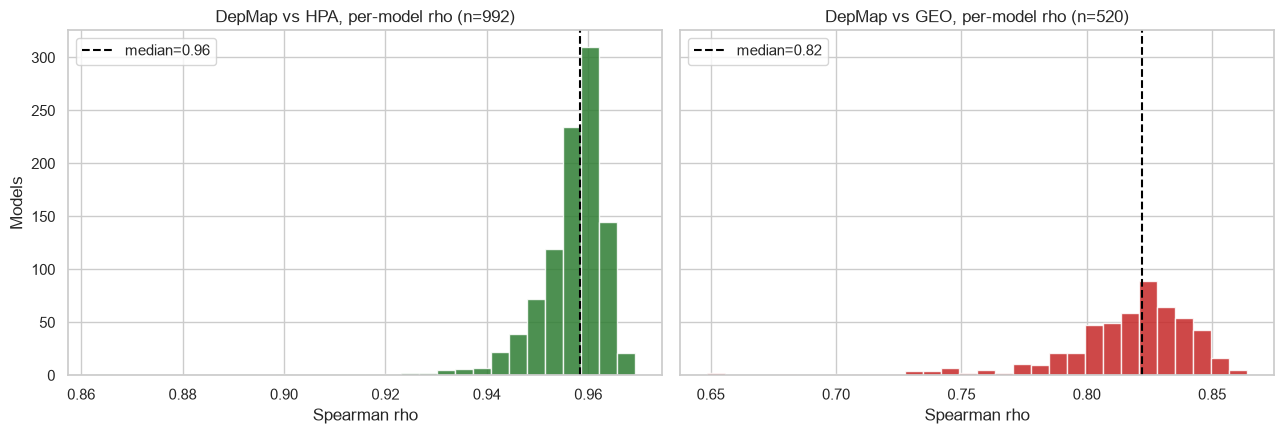

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].hist(dep_hpa_rho.dropna(), bins=30, color='#2E7D32', edgecolor='white', alpha=0.85)
axes[0].axvline(dep_hpa_rho.median(), color='black', linestyle='--', label=f"median={dep_hpa_rho.median():.2f}")
axes[0].set_title(f'DepMap vs HPA, per-model rho (n={len(dep_hpa_rho)})')
axes[0].set_xlabel('Spearman rho'); axes[0].set_ylabel('Models'); axes[0].legend()

axes[1].hist(dep_geo_rho.dropna(), bins=30, color='#C62828', edgecolor='white', alpha=0.85)
axes[1].axvline(dep_geo_rho.median(), color='black', linestyle='--', label=f"median={dep_geo_rho.median():.2f}")
axes[1].set_title(f'DepMap vs GEO, per-model rho (n={len(dep_geo_rho)})')
axes[1].set_xlabel('Spearman rho'); axes[1].legend()

plt.tight_layout()
plt.show()

### Why this EDA check matters

A per-model rho close to 1 across nearly every cell line would mean the two platforms are, for
practical purposes, interchangeable measurements of the same biology -- strong evidence for
`docs/PROJECT_ARCHITECTURE.md` §8's "strength and consistency" confidence design. A wide spread, or
a median well short of 1, is not a data-quality failure by itself (different platforms, different
sensitivities, and real biological noise are all expected to reduce agreement below 1) -- but it
is exactly the kind of "sources disagree" signal §0 and §7 say must be surfaced to the user, never
averaged away. **Correlation only: this does not establish which source, if either, is "more
correct" for any individual gene or model.**

## 7. Lineage-stratified concordance

`docs/PROJECT_ARCHITECTURE.md` §4 requires stratifying by lineage before any pan-cancer statement,
and notebook 02 §6 supplies the floor (`n>=30`) this notebook reuses. The relevant denominator here
is **not** a layer's overall lineage coverage (notebook 02's table) but the lineage breakdown of
*this specific pairwise overlap* -- a lineage well covered by DepMap and well covered by GEO
separately can still be a small overlap once both are required simultaneously, so the actual n used
per lineage is reported here rather than assumed from notebook 02.

In [16]:
lineage_lookup = gated_spine.set_index('model_id')['lineage_canonical']


def lineage_stratified_summary(rho_series: pd.Series) -> pd.DataFrame:
    # Groups a per-model correlation series by lineage_canonical and keeps only lineages whose
    # OVERLAP-SPECIFIC n clears the n>=30 floor -- stricter than, and not assumed equal to, the
    # layer's overall lineage n reported in notebook 02.
    frame = pd.DataFrame({'rho': rho_series, 'lineage': lineage_lookup.reindex(rho_series.index)})
    counts = frame['lineage'].value_counts()
    adequate = counts[counts >= MIN_GROUP_SIZE].index
    out = frame[frame['lineage'].isin(adequate)].groupby('lineage')['rho'].agg(
        n='count', median_rho='median', q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)
    )
    return out.sort_values('n', ascending=False)


dep_hpa_by_lineage = lineage_stratified_summary(dep_hpa_rho)
dep_geo_by_lineage = lineage_stratified_summary(dep_geo_rho)

print(f"DepMap vs HPA -- {len(dep_hpa_by_lineage)} lineages clear n>=30 within this overlap (of {gated_spine['lineage_canonical'].nunique()} total):")
print(dep_hpa_by_lineage)
print()
print(f"DepMap vs GEO -- {len(dep_geo_by_lineage)} lineages clear n>=30 within this overlap (of {gated_spine['lineage_canonical'].nunique()} total):")
print(dep_geo_by_lineage)

DepMap vs HPA -- 13 lineages clear n>=30 within this overlap (of 38 total):
                        n  median_rho       q25       q75
lineage                                                  
Lung                  182    0.959377  0.957022  0.961658
Lymphoid              118    0.950094  0.946212  0.953273
CNS/Brain              64    0.961506  0.959949  0.963431
Esophagus/Stomach      64    0.956707  0.953227  0.958869
Bowel                  59    0.957100  0.952704  0.960046
Breast                 55    0.956915  0.951580  0.959831
Myeloid                54    0.954207  0.950579  0.956512
Skin                   54    0.959133  0.956716  0.961195
Ovary/Fallopian Tube   50    0.960310  0.957763  0.962238
Pancreas               43    0.959281  0.956540  0.960235
Kidney                 37    0.960063  0.956659  0.962332
Head and Neck          35    0.959250  0.955889  0.963600
Uterus                 30    0.960466  0.958355  0.962799

DepMap vs GEO -- 7 lineages clear n>=30 within this o

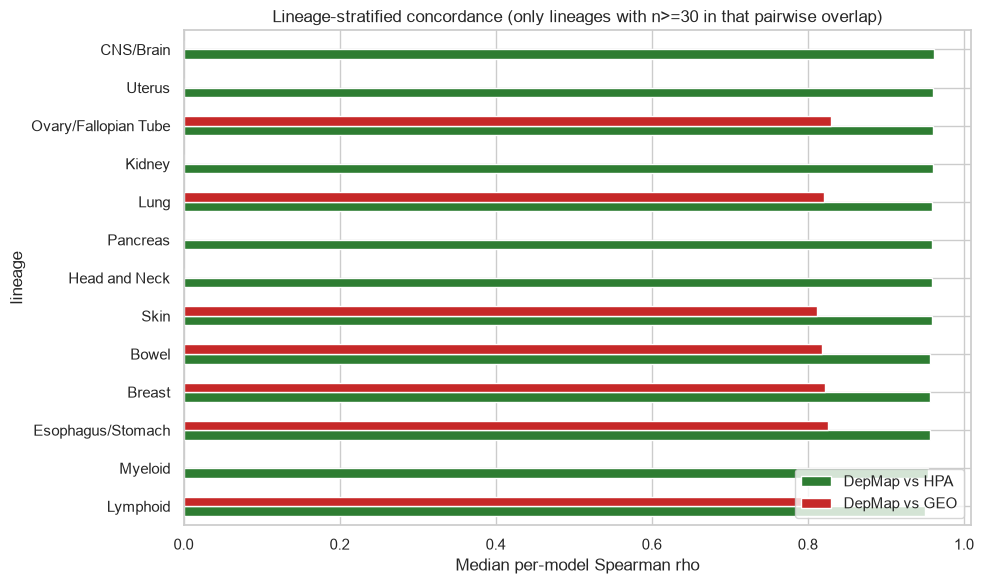

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
combined = pd.concat([
    dep_hpa_by_lineage['median_rho'].rename('DepMap vs HPA'),
    dep_geo_by_lineage['median_rho'].rename('DepMap vs GEO'),
], axis=1)
combined = combined.loc[combined.notna().any(axis=1)].sort_values('DepMap vs HPA', ascending=True)
combined.plot(kind='barh', ax=ax, color=['#2E7D32', '#C62828'])
ax.set_xlabel('Median per-model Spearman rho')
ax.set_title('Lineage-stratified concordance (only lineages with n>=30 in that pairwise overlap)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Why this EDA check matters

If median rho is roughly flat across lineages, agreement is a property of the platform pair, not of
any one cancer type, and a single pan-cancer concordance number is a fair summary. If it varies
systematically, a lineage-specific concordance number (not the pan-cancer average) is the honest
one to attach to a result in that lineage. **Descriptive only -- no significance test is computed,
matching notebook 02 §7's own descriptive-ratio approach**, and no claim is made about *why* any
lineage shows higher or lower agreement (assay batch, tissue-specific RNA quality, and true biology
are all plausible and this comparison cannot separate them).

## 8. Resolving the GEO batch-effect / A3 question

### What single-layer notebook 03 left open

Quoted in full, not paraphrased -- single-layer notebook 03's "Decisions carried into the next
notebooks":

> **Limitation:** GEO pools many independent studies with no shared normalisation pipeline: PCA
> structure here reflects study/platform batch effects at least as much as biology, and this
> notebook does not attempt to separate the two.
>
> Product role: corroboration/breadth only, same as HPA (notebook 01) -- never a standalone scored
> layer without further batch-effect handling (`docs/PROJECT_ARCHITECTURE.md` §6, **A3 calibratable
> criterion is open for this layer pending that work**).

`docs/PROJECT_ARCHITECTURE.md` §6 defines A3 directly: *"Is there a defensible floor and target in
the layer's native unit? A layer that fails cannot enter the arithmetic without inventing
constants."* The filled admission-gate table itself belongs in `docs/plan/METHOD_DECISION.md`,
which does not yet exist on this branch -- this section supplies the evidence that table needs for
GEO RNA's A3 cell, rather than looking up an answer that has not been written yet.

Cross-layer notebook 02 §7 independently measured GEO RNA as the single most lineage-concentrated
layer in the whole primary dataset (top-3-lineage share x1.27 over Lung/Lymphoid/Breast, versus a
1.00 = size-proportional reference) and explicitly flagged it as worth checking whether that bias
also distorts a DepMap-vs-GEO agreement number -- the two questions answered below.

**Question 1** -- is DepMap-vs-GEO agreement meaningfully worse than DepMap-vs-HPA overall?
**Question 2** -- does DepMap-vs-GEO agreement degrade specifically in GEO's own over-represented
lineages (Lung/Lymphoid/Breast) versus other adequately-covered lineages?

In [18]:
overall_hpa_median = dep_hpa_rho.median()
overall_geo_median = dep_geo_rho.median()
gap_hpa_geo = overall_hpa_median - overall_geo_median

print(f"Overall DepMap-vs-HPA median rho (pairwise, n={len(dep_hpa_rho)}): {overall_hpa_median:.3f}")
print(f"Overall DepMap-vs-GEO median rho (pairwise, n={len(dep_geo_rho)}): {overall_geo_median:.3f}")
print(f"Gap (HPA agreement minus GEO agreement):                          {gap_hpa_geo:.3f}")

Overall DepMap-vs-HPA median rho (pairwise, n=992): 0.958
Overall DepMap-vs-GEO median rho (pairwise, n=520): 0.822
Gap (HPA agreement minus GEO agreement):                          0.137


In [19]:
geo_biased_lineages = ['Lung', 'Lymphoid', 'Breast']  # notebook 02 \u00a77's own top-3 for geo_rna, ratio x1.27 -- reused, not re-derived
present_biased = [l for l in geo_biased_lineages if l in dep_geo_by_lineage.index]
present_other = [l for l in dep_geo_by_lineage.index if l not in geo_biased_lineages]

biased_rho = dep_geo_by_lineage.loc[present_biased, 'median_rho']
other_rho = dep_geo_by_lineage.loc[present_other, 'median_rho']

print("DepMap-vs-GEO median rho in GEO's own over-represented lineages (notebook 02 \u00a77):")
print(biased_rho)
print()
print("DepMap-vs-GEO median rho in other adequately-sized lineages:")
print(other_rho)

within_geo_gap = (other_rho.median() - biased_rho.median()) if len(biased_rho) and len(other_rho) else float('nan')
print(f"\nWithin-GEO gap (other lineages minus over-represented lineages): {within_geo_gap:.3f}")

DepMap-vs-GEO median rho in GEO's own over-represented lineages (notebook 02 §7):
lineage
Lung        0.821230
Lymphoid    0.816586
Breast      0.821755
Name: median_rho, dtype: float64

DepMap-vs-GEO median rho in other adequately-sized lineages:
lineage
Bowel                   0.818197
Skin                    0.811928
Esophagus/Stomach       0.826405
Ovary/Fallopian Tube    0.829137
Name: median_rho, dtype: float64

Within-GEO gap (other lineages minus over-represented lineages): 0.001


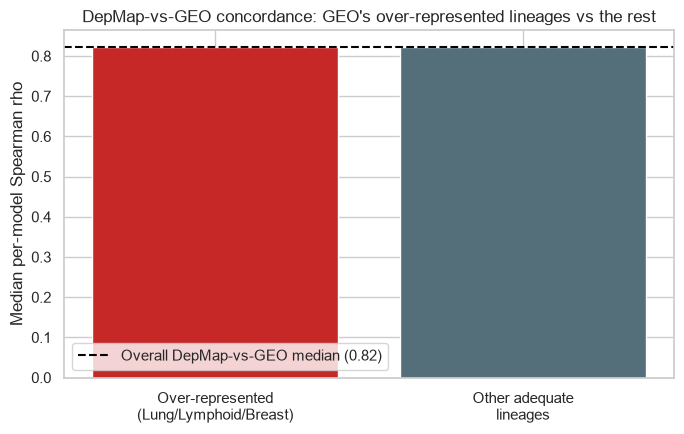

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
group_labels = ['Over-represented\n(Lung/Lymphoid/Breast)', 'Other adequate\nlineages']
group_values = [biased_rho.median(), other_rho.median()]
ax.bar(group_labels, group_values, color=['#C62828', '#546E7A'])
ax.axhline(overall_geo_median, color='black', linestyle='--', label=f'Overall DepMap-vs-GEO median ({overall_geo_median:.2f})')
ax.set_ylabel('Median per-model Spearman rho')
ax.set_title("DepMap-vs-GEO concordance: GEO's over-represented lineages vs the rest")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
GAP_THRESHOLD = 0.10  # a round, stated descriptive threshold for "meaningfully weaker" -- a judgement call, not a fitted cutoff

degrades_vs_hpa = gap_hpa_geo > GAP_THRESHOLD
degrades_in_biased_lineages = (not np.isnan(within_geo_gap)) and (within_geo_gap > GAP_THRESHOLD)

if degrades_vs_hpa or degrades_in_biased_lineages:
    geo_a3_verdict = (
        "GEO RNA is corroboration/breadth only, not independently calibratable for A3: "
        f"DepMap-vs-GEO agreement (median rho={overall_geo_median:.2f}, n={len(dep_geo_rho)}) is "
        f"meaningfully weaker than DepMap-vs-HPA (median rho={overall_hpa_median:.2f}, n={len(dep_hpa_rho)}), "
        "consistent with the pooled-study batch effects single-layer notebook 03 flagged and never resolved."
    )
else:
    geo_a3_verdict = (
        "GEO RNA holds up as a real, if noisier, independent RNA measurement for A3 purposes: "
        f"DepMap-vs-GEO agreement (median rho={overall_geo_median:.2f}, n={len(dep_geo_rho)}) sits "
        f"close to DepMap-vs-HPA (median rho={overall_hpa_median:.2f}, n={len(dep_hpa_rho)}), and does "
        "not degrade specifically in GEO's own over-represented lineages -- the batch-effect risk "
        "single-layer notebook 03 flagged does not, on this evidence, disqualify GEO from a floor/target "
        "A3 definition, though its coverage remains the smallest and most lineage-concentrated of the "
        "three RNA sources and any GEO-derived floor/target should be treated as provisional."
    )

print(f"Gap vs threshold ({GAP_THRESHOLD}):")
print(f"  DepMap-HPA vs DepMap-GEO overall gap:        {gap_hpa_geo:.3f}  {'ABOVE' if degrades_vs_hpa else 'within'} threshold")
print(f"  Within-GEO, other vs over-represented gap:   {within_geo_gap:.3f}  {'ABOVE' if degrades_in_biased_lineages else 'within'} threshold")
print()
print("GEO A3 VERDICT:", geo_a3_verdict)

Gap vs threshold (0.1):
  DepMap-HPA vs DepMap-GEO overall gap:        0.137  ABOVE threshold
  Within-GEO, other vs over-represented gap:   0.001  within threshold

GEO A3 VERDICT: GEO RNA is corroboration/breadth only, not independently calibratable for A3: DepMap-vs-GEO agreement (median rho=0.82, n=520) is meaningfully weaker than DepMap-vs-HPA (median rho=0.96, n=992), consistent with the pooled-study batch effects single-layer notebook 03 flagged and never resolved.


### Why this EDA check matters

This is the single most important output of this notebook. Notebook 05 (the admission-gate
notebook) needs a clear, evidenced verdict for GEO RNA's A3 cell, not a hedge -- the verdict printed
above is computed directly from this notebook's own numbers (not asserted), and is restated in full
in §10's closing summary for notebook 05 to cite directly.

## 9. Biological examples

Spot-checks, not a systematic audit: naming a few specific cell lines by their per-model rho puts a
concrete face on what "agreement" and "disagreement" mean here.

In [22]:
name_lookup = gated_spine.set_index('model_id')['display_name']


def describe_model(model_id: str, rho: float) -> str:
    # Formats one model's id, display name, lineage and per-model correlation for the spot-checks below.
    name = name_lookup.get(model_id, model_id)
    lineage = lineage_lookup.get(model_id, 'unknown')
    return f"{model_id} ({name}, {lineage}): rho={rho:.3f}"


print("DepMap vs HPA -- strongest per-model agreement:")
for m, r in dep_hpa_rho.nlargest(3).items():
    print(" ", describe_model(m, r))
print("DepMap vs HPA -- weakest per-model agreement:")
for m, r in dep_hpa_rho.nsmallest(3).items():
    print(" ", describe_model(m, r))
print()
print("DepMap vs GEO -- strongest per-model agreement:")
for m, r in dep_geo_rho.nlargest(3).items():
    print(" ", describe_model(m, r))
print("DepMap vs GEO -- weakest per-model agreement:")
for m, r in dep_geo_rho.nsmallest(3).items():
    print(" ", describe_model(m, r))

DepMap vs HPA -- strongest per-model agreement:
  ACH-000531 (RS5_FIBROBLAST, Fibroblast): rho=0.969
  ACH-000903 (FTC133_THYROID, Thyroid): rho=0.968
  ACH-000082 (G292CLONEA141B1_BONE, Bone): rho=0.967
DepMap vs HPA -- weakest per-model agreement:
  ACH-001668 (SUSA_TESTIS, Testis): rho=0.863
  ACH-000874 (RS411_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE, Lymphoid): rho=0.894
  ACH-001642 (SCC3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE, Lymphoid): rho=0.901

DepMap vs GEO -- strongest per-model agreement:
  ACH-000696 (OVCAR8_OVARY, Ovary/Fallopian Tube): rho=0.864
  ACH-000767 (NCIH526_LUNG, Lung): rho=0.862
  ACH-000357 (JEKO1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE, Lymphoid): rho=0.861
DepMap vs GEO -- weakest per-model agreement:
  ACH-000523 (NCIH1184_LUNG, Lung): rho=0.649
  ACH-001321 (TT_THYROID, Thyroid): rho=0.654
  ACH-000722 (SNUC1_LARGE_INTESTINE, Bowel): rho=0.684


### Why this EDA check matters

The weakest-agreement lines named above are candidates for an identity-QC follow-up (misidentified
line, wrong default profile, or a genuinely unusual sample) -- **not** a claim that either
measurement is wrong. A single low per-model rho is a flag to investigate, exactly the "why it may
be unsuitable" transparency `docs/PROJECT_ARCHITECTURE.md` §0 and §9's identity-warning principle
call for, never a silent exclusion.

## 10. Candidate feature ideas, limitations, and decisions carried into the next notebooks

### Candidate feature ideas

- **`rna_cross_source_rho` (DepMap-HPA, per model)** -- a direct per-line confidence signal for
  `docs/PROJECT_ARCHITECTURE.md` §8: a model whose RNA cross-source rho sits in the lower tail is a
  candidate for a "cross-source RNA disagreement" flag attached to any result that leans on RNA
  evidence for that line, not a silent average into one number.
- **`rna_cross_source_rho_geo` (DepMap-GEO, per model)**, used only where HPA is unavailable -- a
  weaker, GEO-flavoured corroboration signal per §8's verdict, always labelled as GEO-sourced so a
  user can weigh it accordingly.
- **A per-lineage concordance table** (§7's `dep_hpa_by_lineage` / `dep_geo_by_lineage`), the
  RNA-specific analogue of notebook 02's `lineage_layer_coverage` -- usable as evidence context next
  to any RNA-based result in a lineage this notebook covers.
- **A low-concordance model-level QC flag** (e.g. bottom decile of `rna_cross_source_rho`) as an
  identity/quality warning surfaced under `docs/PROJECT_ARCHITECTURE.md` §0's "why it may be
  unsuitable," not folded into the score itself.

### Limitations

1. **A whole-profile summary, not a per-gene one.** A model's overall rho can be high while any one
   query gene individually disagrees between platforms -- this notebook's per-model rho is a
   model-level QC/confidence signal, not a substitute for checking agreement on the specific gene a
   researcher queries.
2. **Both default-profile ties (DepMap, §5b) and default-GSM ties (GEO, §5d) are ad hoc,
   alphabetical, EDA-only picks.** `preprocessing/` still owes real default-profile rules
   (cross-layer notebook 01 §7) -- this notebook's numbers are reproducible from the raw files given
   this tie-break, but the tie-break itself is not yet a settled pipeline decision.
3. **GEO's single-GSM-per-model collapse discards real replicate information for a majority of
   GEO-reachable models** (§5d) -- averaging was deliberately avoided to keep GEO's per-model value a
   single real measurement rather than a cross-study blend, but this is a real, not cosmetic,
   information loss.
4. **A handful of ambiguous RRID-to-multiple-model bridges are excluded** from the per-model value
   tables (§5c-d), a small (<1%) gap versus §4's presence-flag coverage counts, which grant evidence
   to both resolved models rather than picking one.
5. **Never claim causation.** A low per-model or per-lineage rho is evidence of disagreement between
   two measurement processes -- it is not evidence of which source, if either, is wrong, and it is
   not evidence about the underlying tumour biology.
6. **No significance test is computed anywhere in this notebook** -- medians, IQRs and §8's gap
   threshold are descriptive comparisons, matching notebook 02 §7's own descriptive-ratio convention,
   not inferential statistics.

In [23]:
print("RNA CROSS-SOURCE CONCORDANCE -- SUMMARY FOR NOTEBOOKS 04/05")
print()
print(f"Triple intersection (all 3 sources):  {len(models_triple)} models, {len(genes_triple):,} shared genes")
print(f"DepMap-HPA pairwise intersection:     {len(models_dep_hpa)} models, {len(genes_dep_hpa):,} shared genes")
print(f"DepMap-GEO pairwise intersection:     {len(models_dep_geo)} models, {len(genes_dep_geo):,} shared genes")
print()
print(f"DepMap vs HPA median rho (IQR):  {dep_hpa_rho.median():.3f}  ({dep_hpa_rho.quantile(0.25):.3f} - {dep_hpa_rho.quantile(0.75):.3f})")
print(f"DepMap vs GEO median rho (IQR):  {dep_geo_rho.median():.3f}  ({dep_geo_rho.quantile(0.25):.3f} - {dep_geo_rho.quantile(0.75):.3f})")
print()
hpa_lineage_range = combined['DepMap vs HPA'].dropna()
geo_lineage_range = combined['DepMap vs GEO'].dropna()
print(f"DepMap-HPA lineage-stratified range: {hpa_lineage_range.min():.2f} - {hpa_lineage_range.max():.2f} across {len(hpa_lineage_range)} adequate lineages")
print(f"DepMap-GEO lineage-stratified range: {geo_lineage_range.min():.2f} - {geo_lineage_range.max():.2f} across {len(geo_lineage_range)} adequate lineages")
print()
print("GEO A3 VERDICT (for notebook 05 to cite directly):")
print(geo_a3_verdict)

RNA CROSS-SOURCE CONCORDANCE -- SUMMARY FOR NOTEBOOKS 04/05

Triple intersection (all 3 sources):  479 models, 16,060 shared genes
DepMap-HPA pairwise intersection:     992 models, 19,896 shared genes
DepMap-GEO pairwise intersection:     520 models, 19,894 shared genes

DepMap vs HPA median rho (IQR):  0.958  (0.954 - 0.961)
DepMap vs GEO median rho (IQR):  0.822  (0.805 - 0.834)

DepMap-HPA lineage-stratified range: 0.95 - 0.96 across 13 adequate lineages
DepMap-GEO lineage-stratified range: 0.81 - 0.83 across 7 adequate lineages

GEO A3 VERDICT (for notebook 05 to cite directly):
GEO RNA is corroboration/breadth only, not independently calibratable for A3: DepMap-vs-GEO agreement (median rho=0.82, n=520) is meaningfully weaker than DepMap-vs-HPA (median rho=0.96, n=992), consistent with the pooled-study batch effects single-layer notebook 03 flagged and never resolved.
